Loaded: Figure3_B_plot_inputs.npz
Plotting only — no UMAP or fitting is being run.


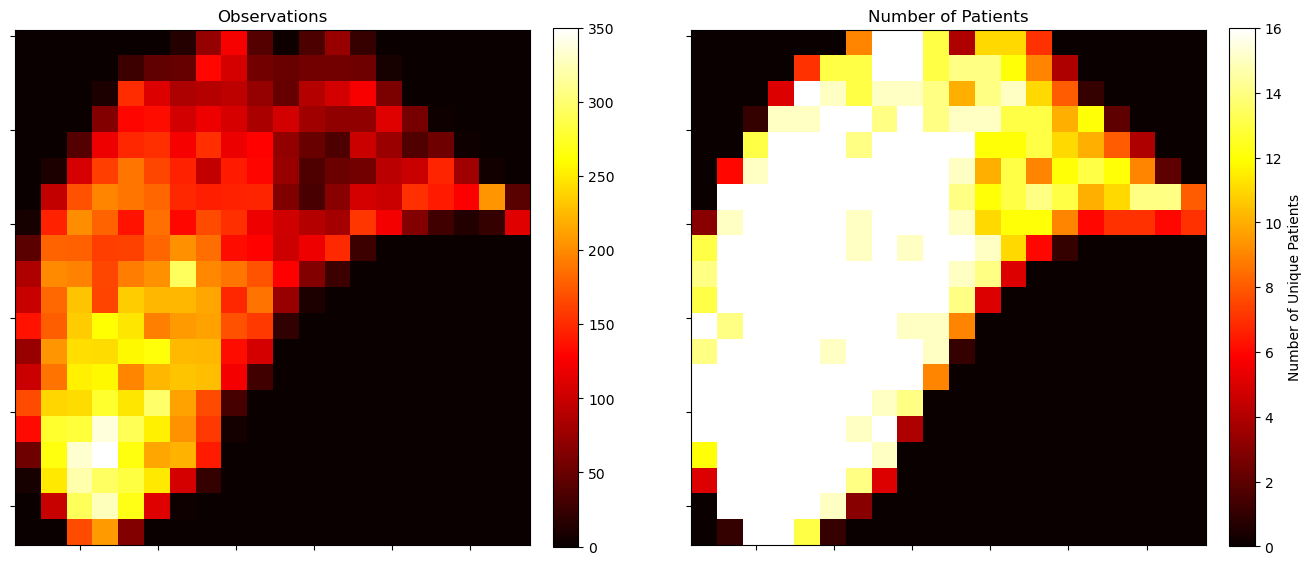

In [1]:
# ============================================================
# PLOT ONLY — START HERE FOR ALL FUTURE REPRODUCTION
#
# No raw .mat loading
# No UMAP
# No fitting
# No recomputation of grid counts
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

CACHE_FILE = "Figure3_B_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    grid_counts = cached["grid_counts"]
    grid_patient_count = cached["grid_patient_count"]
    min_vals = cached["min_vals"]
    max_vals = cached["max_vals"]
    ratio = float(cached["ratio"])
    patient_count = int(cached["patient_count"])

print(f"Loaded: {CACHE_FILE}")
print("Plotting only — no UMAP or fitting is being run.")

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# ------------------------------------------------------------
# Left: Observations
# ------------------------------------------------------------
c1 = axs[0].imshow(
    grid_counts.T,
    origin="lower",
    cmap="hot",
    extent=[
        min_vals[0], max_vals[0],
        min_vals[1], max_vals[1]
    ],
    aspect=1 / ratio,
)

axs[0].set_title("Observations")
axs[0].set_xticklabels([])
axs[0].set_yticklabels([])

fig.colorbar(
    c1,
    ax=axs[0],
    fraction=0.046,
    pad=0.04,
)

c1.set_clim(0, 350)

# ------------------------------------------------------------
# Right: Number of Patients
# ------------------------------------------------------------
c2 = axs[1].imshow(
    grid_patient_count.T,
    origin="lower",
    cmap="hot",
    extent=[
        min_vals[0], max_vals[0],
        min_vals[1], max_vals[1]
    ],
    aspect=1 / ratio,
    vmin=0,
    vmax=patient_count - 1,
)

axs[1].set_title("Number of Patients")
axs[1].set_xticklabels([])
axs[1].set_yticklabels([])

cbar2 = fig.colorbar(
    c2,
    ax=axs[1],
    fraction=0.046,
    pad=0.04,
)

cbar2.set_label("Number of Unique Patients")

ticks = np.arange(0, patient_count, 2)
last_tick = patient_count - 1

if len(ticks) == 0 or ticks[-1] != last_tick:
    ticks = np.append(ticks, last_tick)

cbar2.set_ticks(ticks)
cbar2.set_ticklabels([str(t) for t in ticks])

# Optional:
# plt.savefig(
#     "cross-patient-number_200_ptNum.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()
